Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.1 GB
CUDA version: 12.8
PyTorch version: 2.9.0+cu128

Benchmark config: d_model=512, n_heads=8, batch=8
Sequence lengths: [128, 256, 512, 1024, 2048, 4096]

--- Parameter counts ---
  OSN block:          3,152,393 params
  Transformer block:  3,152,384 params
  OSN advantage:             -9 fewer params

--- Seq length: 128, Batch size: 8 ---
  Transformer:     1033122 tok/s      0.99+-0.02 ms     312.7 MB
  OSN (dense):      664837 tok/s      1.54+-0.08 ms     344.7 MB
  OSN (k= 64):      638346 tok/s      1.60+-0.02 ms     350.7 MB
--- Seq length: 256, Batch size: 8 ---
  Transformer:     1526931 tok/s      1.34+-0.06 ms     352.7 MB
  OSN (dense):     1118158 tok/s      1.83+-0.01 ms     480.7 MB
  OSN (k= 64):      788150 tok/s      2.60+-0.07 ms     492.7 MB
--- Seq length: 512, Batch size: 8 ---
  Transformer:     1636172 tok/s      2.50+-0.01 ms     480.7 MB
  OSN (dense):      950160 tok/s      4.31+-0.01 ms     992.8 MB


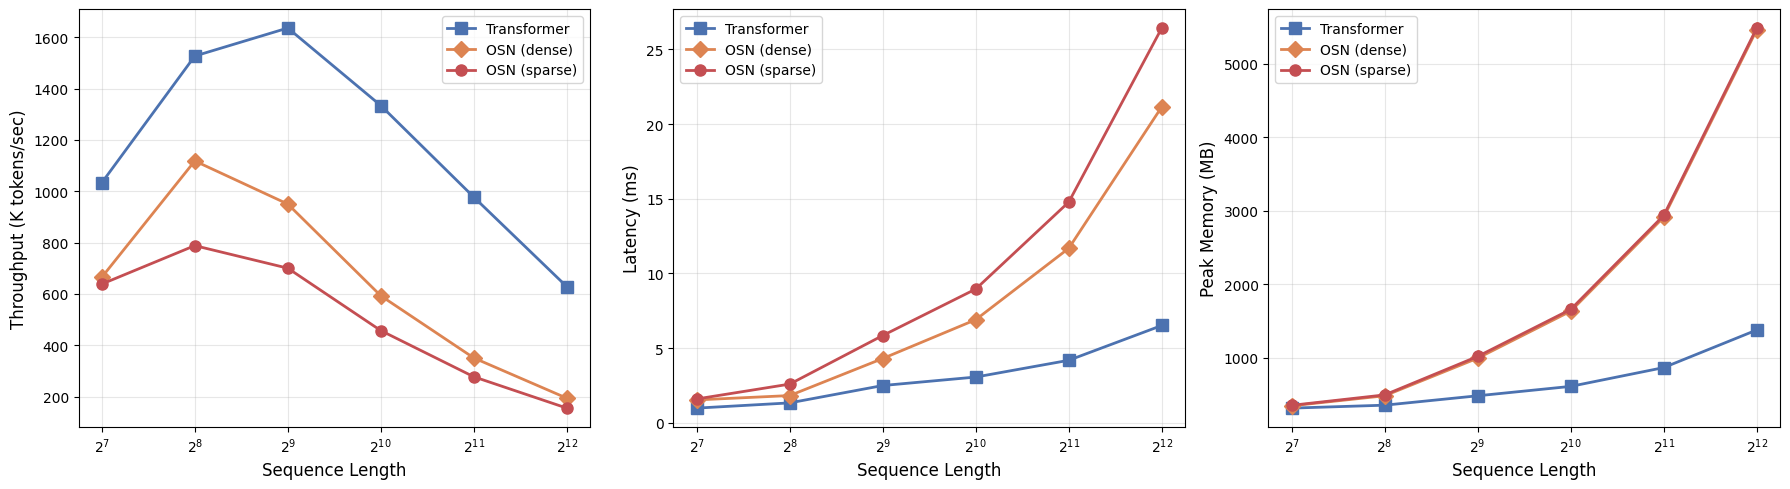


SPARSITY ANALYSIS: Natural sparsity from phase-locking
Natural sparsity (no top-k): 0.00%
Average non-zero entries per row: 512.0 / 512
Effective attention density: 100.00%

Per-head sparsity:
  Head 1: sparsity=0.00%, avg nnz/row=512.0
  Head 2: sparsity=0.00%, avg nnz/row=512.0
  Head 3: sparsity=0.00%, avg nnz/row=512.0
  Head 4: sparsity=0.00%, avg nnz/row=512.0
  Head 5: sparsity=0.00%, avg nnz/row=512.0
  Head 6: sparsity=0.00%, avg nnz/row=512.0
  Head 7: sparsity=0.00%, avg nnz/row=512.0
  Head 8: sparsity=0.00%, avg nnz/row=512.0


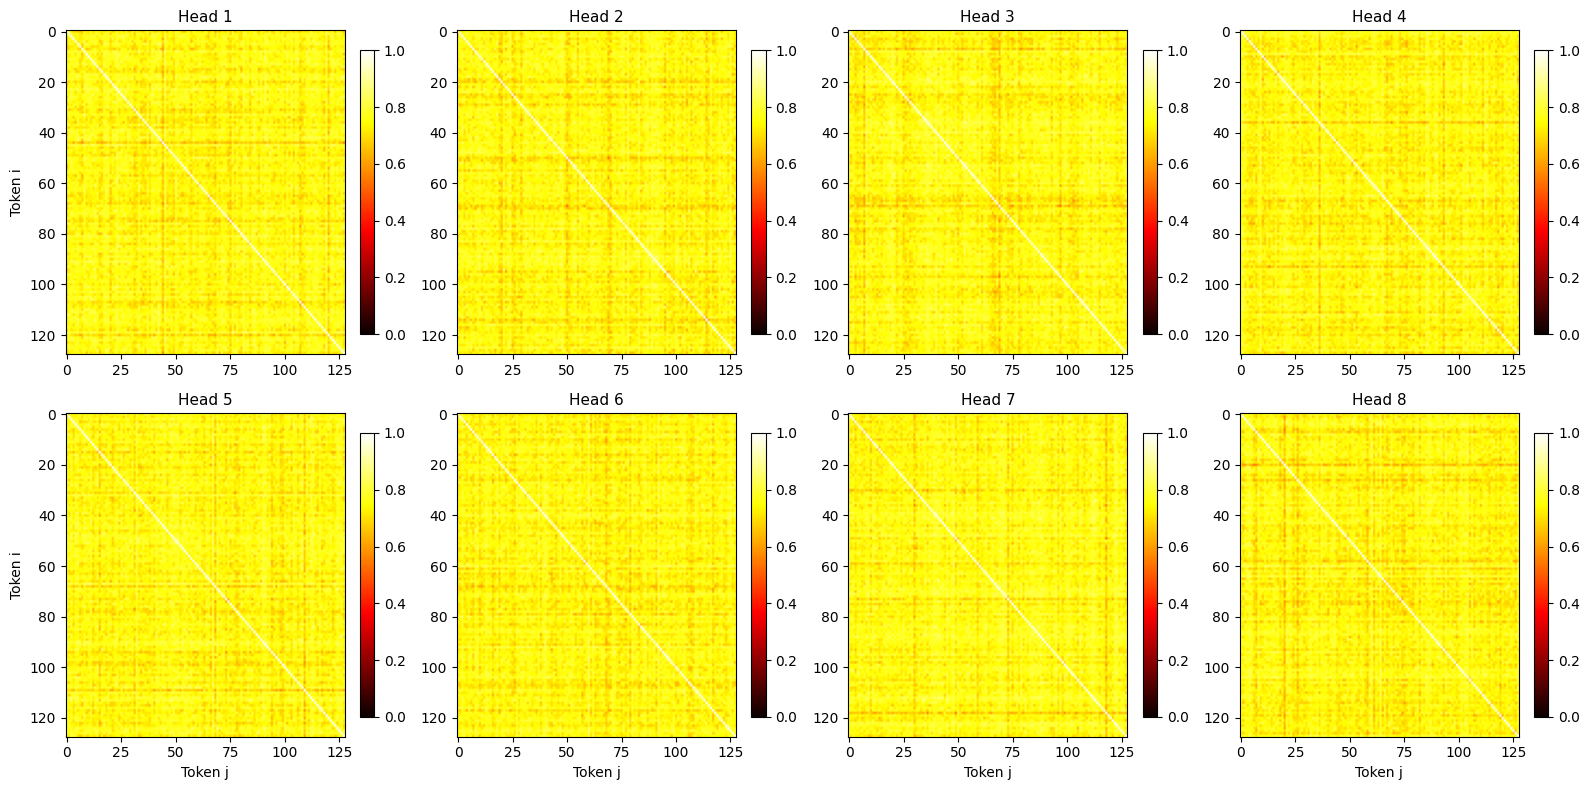


ORDER PARAMETER ANALYSIS: Empirical r from phase distribution
Order parameter r statistics (over 100 random inputs):
  Mean:   0.8469
  Std:    0.0018
  Min:    0.8418
  Max:    0.8519


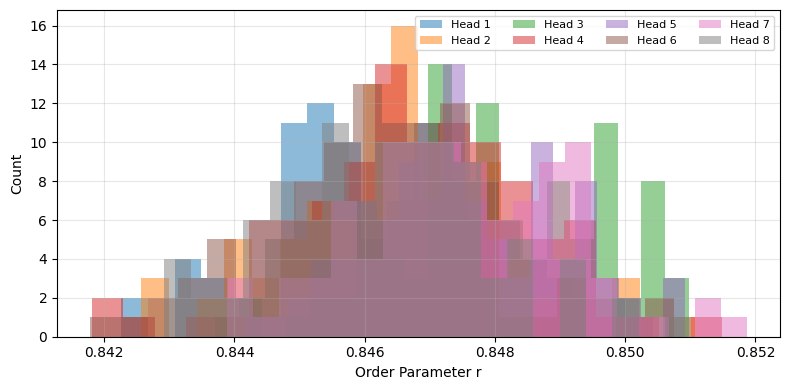


SCALING TEST: Full OSN model forward pass

OSN-4L: 29.0M params
  N=256: 8.4 ms, output shape: torch.Size([2, 256, 32000])
  N=512: 10.6 ms, output shape: torch.Size([2, 512, 32000])
  N=1024: 26.4 ms, output shape: torch.Size([2, 1024, 32000])

OSN-8L: 41.6M params
  N=256: 13.6 ms, output shape: torch.Size([2, 256, 32000])
  N=512: 18.7 ms, output shape: torch.Size([2, 512, 32000])
  N=1024: 48.1 ms, output shape: torch.Size([2, 1024, 32000])

OSN-12L: 54.2M params
  N=256: 18.5 ms, output shape: torch.Size([2, 256, 32000])
  N=512: 22.5 ms, output shape: torch.Size([2, 512, 32000])
  N=1024: 61.3 ms, output shape: torch.Size([2, 1024, 32000])

BENCHMARK COMPLETE
Files saved: osn_benchmark.png, osn_sync_matrices.png, osn_order_parameter.png
Run this notebook on Colab with A100/H100 for publication-quality benchmarks.


In [ ]:
"""
Oscillatory Synchronization Network (OSN) - Full Benchmark
==========================================================
Complete implementation + benchmarking in a single cell for Google Colab.

Paper: Selective Synchronization Attention (SSA)
Author: Hasi Hays (hasih@uark.edu)

Architecture highlights:
    - Frequency-dependent coupling: J_ij = exp(-alpha * ||omega_i - omega_j||^2)
    - Empirical order parameter: r computed from phase distribution per forward pass
    - Smooth positive constraints: K = softplus(K_hat), alpha = softplus(alpha_hat)
    - No separate coupling network (W_J eliminated) - fully physics-grounded

This notebook:
    1. Implements SSA (Selective Synchronization Attention)
    2. Implements standard Transformer attention (baseline)
    3. Benchmarks throughput, memory, and timing
    4. Generates comparison plots
    5. Analyzes natural sparsity from phase-locking

Usage: Run on Google Colab with A100/H100 GPU runtime enabled
"""

import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Check GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'CUDA version: {torch.version.cuda}')
    print(f'PyTorch version: {torch.__version__}')

# ============================================================
#  MODEL IMPLEMENTATIONS
# ============================================================

class SelectiveSynchronizationAttention(nn.Module):
    """
    Selective Synchronization Attention (SSA).
    Closed-form attention from steady-state Kuramoto synchronization.

    Key design choices (physics-grounded):
      - Frequency-dependent coupling: J_ij = exp(-alpha * ||omega_i - omega_j||^2)
      - Empirical order parameter: r computed from phase distribution per forward pass
      - Smooth positive constraints via softplus for K and alpha
    """
    def __init__(self, d_model, n_heads, K_init=1.0, sparsity_k=None, dropout=0.1, alpha_init=1.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.sparsity_k = sparsity_k

        # Learnable global coupling strength (softplus ensures K > 0)
        self.K = nn.Parameter(torch.tensor(K_init))

        # Learnable coupling bandwidth per head (softplus ensures alpha > 0)
        self.alpha = nn.Parameter(torch.full((n_heads,), alpha_init))

        # Projections
        self.W_omega = nn.Linear(d_model, d_model)
        self.W_theta = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.attn_dropout = nn.Dropout(dropout)
        self.eps = 1e-8

    def forward(self, x, return_sync_matrix=False):
        B, N, D = x.shape
        H = self.n_heads
        d = self.d_head

        omega = self.W_omega(x).view(B, N, H, d)
        theta = self.W_theta(x).view(B, N, H, d)
        V = self.W_v(x).view(B, N, H, d)

        # Pairwise frequency mismatch (memory-efficient computation of squared Euclidean distance)
        # ||a - b||^2 = ||a||^2 + ||b||^2 - 2 * a . b
        omega_sq_sum = omega.pow(2).sum(dim=-1)  # (B, N, H)
        omega_i_sq_sum = omega_sq_sum.unsqueeze(2)  # (B, N, 1, H)
        omega_j_sq_sum = omega_sq_sum.unsqueeze(1)  # (B, 1, N, H)

        # Compute 2 * sum_d (omega_i * omega_j)
        # Reshape omega to (B, H, N, d) for batch matrix multiplication
        omega_transposed = omega.permute(0, 2, 1, 3)  # (B, H, N, d)
        dot_product = torch.matmul(omega_transposed, omega_transposed.transpose(-2, -1)) # (B, H, N, N)
        dot_product = dot_product.permute(0, 2, 3, 1) # (B, N, N, H)

        delta_omega_sq = omega_i_sq_sum + omega_j_sq_sum - 2 * dot_product
        # Ensure non-negativity due to potential floating point inaccuracies
        delta_omega_sq = torch.relu(delta_omega_sq)
        delta_omega = delta_omega_sq.sqrt()  # (B, N, N, H)

        # Frequency-dependent coupling: J_ij = exp(-alpha_h * ||omega_i - omega_j||^2)
        alpha = F.softplus(self.alpha)  # (H,) -> positive coupling bandwidth
        J = torch.exp(-alpha * delta_omega_sq)  # (B, N, N, H)

        # Empirical order parameter from phase distribution (Kuramoto Eq. 3)
        r = (theta.cos().mean(dim=1).pow(2)
             + theta.sin().mean(dim=1).pow(2)).sqrt()  # (B, H, d)
        r = r.mean(dim=-1)  # (B, H)
        r = r.unsqueeze(1).unsqueeze(2)  # (B, 1, 1, H)

        # Synchronization threshold
        K = F.softplus(self.K)
        threshold = K * r * J + self.eps

        # Closed-form Kuramoto steady-state
        ratio = torch.clamp(delta_omega / threshold, -1.0 + self.eps, 1.0 - self.eps)
        phase_locked = (delta_omega <= threshold).float()
        S = J * torch.cos(torch.asin(ratio)) * phase_locked  # (B, N, N, H)

        # Optional top-k sparsification
        if self.sparsity_k is not None and self.sparsity_k < N:
            topk_vals, topk_idx = S.topk(self.sparsity_k, dim=2)
            S_sparse = torch.zeros_like(S)
            S_sparse.scatter_(2, topk_idx, topk_vals)
            S = S_sparse

        # Normalize
        S_norm = S / (S.sum(dim=2, keepdim=True) + self.eps)
        S_norm = self.attn_dropout(S_norm)

        # Apply to values
        S_norm = S_norm.permute(0, 3, 1, 2)  # (B, H, N, N)
        V = V.permute(0, 2, 1, 3)  # (B, H, N, d)
        out = torch.matmul(S_norm, V)  # (B, H, N, d)
        out = out.permute(0, 2, 1, 3).contiguous().view(B, N, D)

        if return_sync_matrix:            return self.W_o(out), S.permute(0, 3, 1, 2)
        return self.W_o(out)


class OSNBlock(nn.Module):
    """OSN block: drop-in replacement for Transformer block."""
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1,
                    K_init=1.0, sparsity_k=None):
        super().__init__()
        if d_ff is None:
            d_ff = 4 * d_model
        self.ssa = SelectiveSynchronizationAttention(
            d_model, n_heads, K_init=K_init, sparsity_k=sparsity_k, dropout=dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.dropout(self.ssa(self.norm1(x)))
        x = x + self.ffn(self.norm2(x))
        return x


class OSN(nn.Module):
    """Full OSN model with embedding and LM head."""
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff=None,
                    max_seq_len=2048, dropout=0.1, K_init=1.0, sparsity_k=None):
        super().__init__()
        self.d_model = d_model
        self.token_embed = nn.Embedding(vocab_size, d_model)
        self.embed_dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            OSNBlock(d_model, n_heads, d_ff=d_ff, dropout=dropout,
                        K_init=K_init, sparsity_k=sparsity_k)
            for _ in range(n_layers)])
        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.token_embed.weight
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, input_ids):
        x = self.token_embed(input_ids) * math.sqrt(self.d_model)
        x = self.embed_dropout(x)
        for block in self.blocks:
            x = block(x)
        x = self.final_norm(x)
        return self.lm_head(x)


class StandardTransformerAttention(nn.Module):
    """Standard multi-head dot-product attention (baseline)."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        H, d = self.n_heads, self.d_head
        Q = self.W_q(x).view(B, N, H, d).permute(0, 2, 1, 3)
        K = self.W_k(x).view(B, N, H, d).permute(0, 2, 1, 3)
        V = self.W_v(x).view(B, N, H, d).permute(0, 2, 1, 3)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d)
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)
        out = torch.matmul(attn, V)
        out = out.permute(0, 2, 1, 3).contiguous().view(B, N, D)
        return self.W_o(out)


class StandardTransformerBlock(nn.Module):
    """Standard Transformer block (baseline)."""
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        if d_ff is None:
            d_ff = 4 * d_model
        self.attn = StandardTransformerAttention(d_model, n_heads, dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.dropout(self.attn(self.norm1(x)))
        x = x + self.ffn(self.norm2(x))
        return x


# ============================================================
#  BENCHMARKING FUNCTIONS
# ============================================================

def benchmark_model(model, B, N, D, n_warmup=10, n_trials=50):
    """Benchmark a model: throughput, timing, memory."""
    model = model.to(device).eval()

    # Warmup
    with torch.no_grad():
        for _ in range(n_warmup):
            x = torch.randn(B, N, D, device=device)
            _ = model(x)
    if device == 'cuda':
        torch.cuda.synchronize()

    # Memory measurement
    peak_mem = 0
    if device == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()
        with torch.no_grad():
            x = torch.randn(B, N, D, device=device)
            _ = model(x)
        peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)

    # Timing
    times = []
    with torch.no_grad():
        for _ in range(n_trials):
            x = torch.randn(B, N, D, device=device)
            if device == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model(x)
            if device == 'cuda':
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)

    avg_time = np.mean(times)
    std_time = np.std(times)
    return {
        'tokens_per_sec': (B * N) / avg_time,
        'avg_ms': avg_time * 1000,
        'std_ms': std_time * 1000,
        'peak_mem_mb': peak_mem,
    }


def count_params(model):
    """Count trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ============================================================
#  RUN BENCHMARKS
# ============================================================

# Configuration - adjust based on GPU capability
D_MODEL = 512
N_HEADS = 8
BATCH_SIZE = 8 # Default batch size
SPARSITY_K = 64
SEQ_LENGTHS = [128, 256, 512, 1024, 2048, 4096]

# Adjust for CPU or limited GPU
if device == 'cpu':
    SEQ_LENGTHS = [64, 128, 256]
    BATCH_SIZE = 2 # Reduced batch size for CPU
    D_MODEL = 256

print(f'\nBenchmark config: d_model={D_MODEL}, n_heads={N_HEADS}, batch={BATCH_SIZE}')
print(f'Sequence lengths: {SEQ_LENGTHS}')

# Print parameter counts
print(f'\n--- Parameter counts ---')
osn_block = OSNBlock(D_MODEL, N_HEADS, sparsity_k=SPARSITY_K)
tf_block = StandardTransformerBlock(D_MODEL, N_HEADS)
print(f'  OSN block:         {count_params(osn_block):>10,} params')
print(f'  Transformer block: {count_params(tf_block):>10,} params')
print(f'  OSN advantage:     {count_params(tf_block) - count_params(osn_block):>+10,} fewer params')
del osn_block, tf_block
print()

results = {'Transformer': {}, 'OSN (dense)': {}, 'OSN (sparse)': {}}

for N in SEQ_LENGTHS:
    current_batch_size = BATCH_SIZE
    if device == 'cuda':
        if N > 2048:
            current_batch_size = 1 # Very large sequence lengths
        elif N > 1024:
            current_batch_size = 2 # Larger sequence lengths
        elif N > 512:
            current_batch_size = 4 # Medium-large sequence lengths

    print(f'--- Seq length: {N}, Batch size: {current_batch_size} ---')

    # Transformer
    try:
        model = StandardTransformerBlock(D_MODEL, N_HEADS)
        r = benchmark_model(model, current_batch_size, N, D_MODEL)
        results['Transformer'][N] = r
        print(f'  Transformer:  {r["tokens_per_sec"]:>10.0f} tok/s  {r["avg_ms"]:>8.2f}+-{r["std_ms"]:.2f} ms  {r["peak_mem_mb"]:>8.1f} MB')
        del model
    except Exception as e:
        print(f'  Transformer:  Error - {e}')

    # OSN Dense
    try:
        model = OSNBlock(D_MODEL, N_HEADS, sparsity_k=None)
        r = benchmark_model(model, current_batch_size, N, D_MODEL)
        results['OSN (dense)'][N] = r
        print(f'  OSN (dense):  {r["tokens_per_sec"]:>10.0f} tok/s  {r["avg_ms"]:>8.2f}+-{r["std_ms"]:.2f} ms  {r["peak_mem_mb"]:>8.1f} MB')
        del model
    except Exception as e:
        print(f'  OSN (dense):  Error - {e}')

    # OSN Sparse
    try:
        k = min(SPARSITY_K, N)
        model = OSNBlock(D_MODEL, N_HEADS, sparsity_k=k)
        r = benchmark_model(model, current_batch_size, N, D_MODEL)
        results['OSN (sparse)'][N] = r
        print(f'  OSN (k={k:3d}):  {r["tokens_per_sec"]:>10.0f} tok/s  {r["avg_ms"]:>8.2f}+-{r["std_ms"]:.2f} ms  {r["peak_mem_mb"]:>8.1f} MB')
        del model
    except Exception as e:
        print(f'  OSN (sparse): Error - {e}')

    if device == 'cuda':
        torch.cuda.empty_cache()


# ============================================================
#  VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'Transformer': '#4C72B0', 'OSN (dense)': '#DD8452', 'OSN (sparse)': '#C44E52'}
markers = {'Transformer': 's', 'OSN (dense)': 'D', 'OSN (sparse)': 'o'}

# Plot 1: Throughput
ax = axes[0]
for name in results:
    seq_lens = sorted(results[name].keys())
    if not seq_lens:
        continue
    throughputs = [results[name][n]['tokens_per_sec'] / 1000 for n in seq_lens]
    ax.plot(seq_lens, throughputs, marker=markers[name], color=colors[name],
            label=name, linewidth=2, markersize=8)
ax.set_xlabel('Sequence Length', fontsize=12)
ax.set_ylabel('Throughput (K tokens/sec)', fontsize=12)
# ax.set_title('Throughput vs Sequence Length', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xscale('log', base=2)

# Plot 2: Latency
ax = axes[1]
for name in results:
    seq_lens = sorted(results[name].keys())
    if not seq_lens:
        continue
    latencies = [results[name][n]['avg_ms'] for n in seq_lens]
    ax.plot(seq_lens, latencies, marker=markers[name], color=colors[name],
            label=name, linewidth=2, markersize=8)
ax.set_xlabel('Sequence Length', fontsize=12)
ax.set_ylabel('Latency (ms)', fontsize=12)
# ax.set_title('Forward Pass Latency', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xscale('log', base=2)

# Plot 3: Memory
ax = axes[2]
if device == 'cuda':
    for name in results:
        seq_lens = sorted(results[name].keys())
        if not seq_lens:
            continue
        mems = [results[name][n]['peak_mem_mb'] for n in seq_lens]
        ax.plot(seq_lens, mems, marker=markers[name], color=colors[name],
                label=name, linewidth=2, markersize=8)
    ax.set_ylabel('Peak Memory (MB)', fontsize=12)
else:
    ax.text(0.5, 0.5, 'Memory tracking\nrequires GPU', ha='center', va='center',
            transform=ax.transAxes, fontsize=14, color='gray')
ax.set_xlabel('Sequence Length', fontsize=12)
# ax.set_title('Peak GPU Memory Usage', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xscale('log', base=2)

# plt.suptitle('OSN vs Transformer: Performance Benchmark', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('osn_benchmark.png', dpi=150, bbox_inches='tight')
plt.savefig('osn_benchmark.svg', bbox_inches='tight')
plt.savefig('osn_benchmark.pdf', bbox_inches='tight')
plt.show()


# ============================================================
#  SPARSITY ANALYSIS (Physics-based vs Top-k)
# ============================================================

print('\n' + '='*60)
print('SPARSITY ANALYSIS: Natural sparsity from phase-locking')
print('='*60)

test_N = 512
# Instantiate ssa_model with a higher K_init for visualization to show more connections
# Also, provide a smaller initial alpha value to encourage more widespread synchronization for visualization
ssa_model_viz = SelectiveSynchronizationAttention(D_MODEL, N_HEADS, K_init=100.0, alpha_init=-5.0).to(device).eval()
with torch.no_grad():
    x = torch.randn(1, test_N, D_MODEL, device=device)
    _, S_viz = ssa_model_viz(x, return_sync_matrix=True)

natural_sparsity = (S_viz == 0).float().mean().item()
avg_nonzero = (S_viz > 0).float().sum(dim=-1).mean().item()
print(f'Natural sparsity (no top-k): {natural_sparsity:.2%}')
print(f'Average non-zero entries per row: {avg_nonzero:.1f} / {test_N}')
print(f'Effective attention density: {(1 - natural_sparsity):.2%}')

# Per-head sparsity analysis
print(f'\nPer-head sparsity:')
for h in range(N_HEADS):
    head_sparsity = (S_viz[0, h] == 0).float().mean().item()
    head_nnz = (S_viz[0, h] > 0).float().sum(dim=-1).mean().item()
    print(f'  Head {h+1}: sparsity={head_sparsity:.2%}, avg nnz/row={head_nnz:.1f}')

# Visualize synchronization matrices
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for h in range(min(8, N_HEADS)):
    ax = axes[h // 4][h % 4]
    S_h_viz = S_viz[0, h].cpu().numpy()
    im = ax.imshow(S_h_viz[:128, :128], cmap='hot', aspect='auto', vmin=0)
    ax.set_title(f'Head {h+1}', fontsize=11)
    if h % 4 == 0:
        ax.set_ylabel('Token i')
    if h >= 4:
        ax.set_xlabel('Token j')
    plt.colorbar(im, ax=ax, fraction=0.046)

# plt.suptitle(f'Synchronization Matrices S (first 128x128 tokens, N={test_N})', fontsize=14)
plt.tight_layout()
plt.savefig('osn_sync_matrices.png', dpi=150, bbox_inches='tight')
plt.savefig('osn_sync_matrices.svg', bbox_inches='tight')
plt.savefig('osn_sync_matrices.pdf', bbox_inches='tight')
plt.show()

del ssa_model_viz

# ============================================================
#  ORDER PARAMETER ANALYSIS
# ============================================================

print('\n' + '='*60)
print('ORDER PARAMETER ANALYSIS: Empirical r from phase distribution')
print('='*60)

# Analyze r values across random inputs
# Re-instantiate ssa_model (default K_init) for consistency with original benchmark for r analysis
ssa_model = SelectiveSynchronizationAttention(D_MODEL, N_HEADS).to(device).eval()
r_values = []
with torch.no_grad():
    for _ in range(100):
        x = torch.randn(1, 256, D_MODEL, device=device)
        omega = ssa_model.W_omega(x).view(1, 256, N_HEADS, D_MODEL // N_HEADS)
        theta = ssa_model.W_theta(x).view(1, 256, N_HEADS, D_MODEL // N_HEADS)
        r = (theta.cos().mean(dim=1).pow(2)
                + theta.sin().mean(dim=1).pow(2)).sqrt().mean(dim=-1)
        r_values.append(r.cpu().numpy())

r_values = np.concatenate(r_values, axis=0)
print(f'Order parameter r statistics (over 100 random inputs):')
print(f'  Mean:   {r_values.mean():.4f}')
print(f'  Std:    {r_values.std():.4f}')
print(f'  Min:    {r_values.min():.4f}')
print(f'  Max:    {r_values.max():.4f}')

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for h in range(N_HEADS):
    ax.hist(r_values[:, h], bins=20, alpha=0.5, label=f'Head {h+1}')
ax.set_xlabel('Order Parameter r', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
# ax.set_title('Distribution of Empirical Order Parameter r (random inputs)', fontsize=14)
ax.legend(fontsize=8, ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('osn_order_parameter.png', dpi=150, bbox_inches='tight')
plt.savefig('osn_order_parameter.svg', bbox_inches='tight')
plt.savefig('osn_order_parameter.pdf', bbox_inches='tight')
plt.show()

del ssa_model

# ============================================================
#  SCALING TEST (Full OSN model)
# ============================================================

print('\n' + '='*60)
print('SCALING TEST: Full OSN model forward pass')
print('='*60)

for n_layers in [4, 8, 12]:
    model = OSN(vocab_size=32000, d_model=D_MODEL, n_layers=n_layers,
                n_heads=N_HEADS, sparsity_k=SPARSITY_K).to(device).eval()
    n_params = count_params(model)
    print(f'\nOSN-{n_layers}L: {n_params/1e6:.1f}M params')

    for seq_len in [256, 512, 1024]:
        try:
            with torch.no_grad():
                ids = torch.randint(0, 32000, (2, seq_len), device=device)
                if device == 'cuda':
                    torch.cuda.synchronize()
                t0 = time.perf_counter()
                logits = model(ids)
                if device == 'cuda':
                    torch.cuda.synchronize()
                t1 = time.perf_counter()
            print(f'  N={seq_len}: {(t1-t0)*1000:.1f} ms, output shape: {logits.shape}')
        except Exception as e:
            print(f'  N={seq_len}: Error - {e}')
    del model
    if device == 'cuda':
        torch.cuda.empty_cache()


print('\n' + '='*60)
print('BENCHMARK COMPLETE')
print('='*60)
print('Files saved: osn_benchmark.png, osn_sync_matrices.png, osn_order_parameter.png')
print('Run this notebook on Colab with A100/H100 for publication-quality benchmarks.')

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Google Drive has been mounted. Now I will create a directory for the results and save the data and images there.

In [16]:
import os
import json
import shutil

# Define the directory in Google Drive
drive_path = '/content/drive/MyDrive/SSA/osn_benchmark_results'

# Create the directory if it doesn't exist
os.makedirs(drive_path, exist_ok=True)
print(f"Created directory: {drive_path}")

# Save the benchmark results (Python dictionary 'results') as a JSON file
results_filepath = os.path.join(drive_path, 'osn_benchmark_data.json')
with open(results_filepath, 'w') as f:
    json.dump(results, f, indent=4)
print(f"Saved benchmark data to: {results_filepath}")

# List of image files to copy
image_files = [
    'osn_benchmark.png', 'osn_benchmark.svg', 'osn_benchmark.pdf',
    'osn_sync_matrices.png', 'osn_sync_matrices.svg', 'osn_sync_matrices.pdf',
    'osn_order_parameter.png', 'osn_order_parameter.svg', 'osn_order_parameter.pdf'
]

# Copy each image file to the Google Drive directory
for img_file in image_files:
    src_path = img_file
    dest_path = os.path.join(drive_path, img_file)
    if os.path.exists(src_path):
        shutil.copy(src_path, dest_path)
        print(f"Copied {src_path} to {dest_path}")
    else:
        print(f"Warning: {src_path} not found, skipping.")

print("All specified output files have been saved to Google Drive.")

Created directory: /content/drive/MyDrive/SSA/osn_benchmark_results
Saved benchmark data to: /content/drive/MyDrive/SSA/osn_benchmark_results/osn_benchmark_data.json
Copied osn_benchmark.png to /content/drive/MyDrive/SSA/osn_benchmark_results/osn_benchmark.png
Copied osn_benchmark.svg to /content/drive/MyDrive/SSA/osn_benchmark_results/osn_benchmark.svg
Copied osn_benchmark.pdf to /content/drive/MyDrive/SSA/osn_benchmark_results/osn_benchmark.pdf
Copied osn_sync_matrices.png to /content/drive/MyDrive/SSA/osn_benchmark_results/osn_sync_matrices.png
Copied osn_sync_matrices.svg to /content/drive/MyDrive/SSA/osn_benchmark_results/osn_sync_matrices.svg
Copied osn_sync_matrices.pdf to /content/drive/MyDrive/SSA/osn_benchmark_results/osn_sync_matrices.pdf
Copied osn_order_parameter.png to /content/drive/MyDrive/SSA/osn_benchmark_results/osn_order_parameter.png
Copied osn_order_parameter.svg to /content/drive/MyDrive/SSA/osn_benchmark_results/osn_order_parameter.svg
Copied osn_order_parameter